# Notebook 1 — Advanced Nonlinear Time-Series Ensemble Model
## Flood-Relief Resource Demand Forecasting · Coastal Odisha Districts

---

### Overview

This notebook builds a **multi-component ensemble forecasting pipeline** for daily water-demand
prediction across six coastal Odisha districts (Puri, Ganjam, Kendrapara, Balasore, Bhadrak,
Jagatsinghpur). The modelling philosophy is inspired by the idea that disaster demand is driven
by at least *four overlapping data-generating processes*:

1. **Smooth, periodic climate cycles** — monsoon seasonality, annual temperature rhythm
2. **Heterogeneous autoregressive memory** — short-burst (daily), medium (weekly), long (monthly)
3. **Non-linear threshold effects** — gauge-level crossings, cyclone wind thresholds
4. **Stochastic irregular shocks** — unexplained residuals captured by Bayesian uncertainty

No single model handles all four well. We therefore estimate each component separately and
combine them via an **ARDL-ECM meta-model** that maintains long-run equilibrium.

---

### Mathematical Roadmap

Let $y_t$ denote `target_water_liters_demand` at time $t$ for a given district.
Our full data-generating model is:

$$
y_t = \underbrace{f_{\text{SC}}(t)}_{\text{sine-cosine}} +
      \underbrace{f_{\text{HAR}}(y_{t-1}, y_{t-7}, y_{t-30})}_{\text{HAR}} +
      \underbrace{f_{\text{SARIMA}}(B)}_{\text{SARIMA}} +
      \underbrace{f_{\text{WVL}}(\mathbf{W}_t)}_{\text{wavelet}} +
      \underbrace{f_{\text{FDA}}(\mathbf{X}_t)}_{\text{functional}} +
      \underbrace{f_{\text{ARDL}}(\mathbf{z}_t)}_{\text{ARDL-ECM}} +
      \epsilon_t
$$

where $\epsilon_t \sim \mathcal{N}(0, \sigma^2)$ under Bayesian treatment.

## 0. Environment Setup

In [1]:
# Install dependencies (run once)
import subprocess, sys
packages = [
    'statsmodels', 'pywavelets', 'geopy', 'scikit-learn',
    'scipy', 'matplotlib', 'seaborn', 'joblib'
]
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=False)

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import os

from scipy import signal, stats
from scipy.optimize import minimize
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

try:
    import statsmodels.api as sm
    from statsmodels.tsa.stattools import adfuller, coint
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.tsa.seasonal import seasonal_decompose
    HAVE_SM = True
except ImportError:
    HAVE_SM = False
    print('statsmodels not available — SARIMA section will use scipy fallback')

try:
    import pywt
    HAVE_PWT = True
except ImportError:
    HAVE_PWT = False
    print('PyWavelets not available — using built-in Haar implementation')

try:
    from geopy.distance import geodesic
    from geopy.geocoders import Nominatim
    HAVE_GEOPY = True
except ImportError:
    HAVE_GEOPY = False
    print('geopy not available — using manual geodesic formula')

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['axes.grid'] = True
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)
print('Setup complete.')

Setup complete.


## 1. Data Loading & Path Configuration

In [3]:
# ─── EDIT THIS PATH ────────────────────────────────────────────────────────
DATA_PATH = r'C:\Users\pragy\Downloads\other_open_projects\NSS open Projects\master_dataset.csv'
MODEL_DIR = os.path.dirname(DATA_PATH)   # models saved alongside the CSV
os.makedirs(MODEL_DIR, exist_ok=True)
# ───────────────────────────────────────────────────────────────────────────

df = pd.read_csv(DATA_PATH, low_memory=False, parse_dates=['date'])
df = df.sort_values(['district', 'date']).reset_index(drop=True)

print(f'Loaded {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Districts  : {df["district"].unique().tolist()}')

Loaded 32,874 rows × 67 columns
Date range : 2010-01-01 → 2024-12-31
Districts  : ['Balasore', 'Bhadrak', 'Ganjam', 'Jagatsinghpur', 'Kendrapara', 'Puri']


## 2. Geospatial Feature Engineering (geopy)

### Mathematical basis

We use the **Haversine / WGS-84 Vincenty formula** to compute great-circle distances
between district centroids and hazard reference points (Bay of Bengal coast, cyclone
landfall markers). The haversine formula is:

$$
d = 2R \arcsin\!\left(\sqrt{\sin^2\!\left(\frac{\phi_2-\phi_1}{2}\right)
    + \cos\phi_1 \cos\phi_2 \sin^2\!\left(\frac{\lambda_2-\lambda_1}{2}\right)}\right)
$$

where $R=6371$ km, $(\phi_i, \lambda_i)$ are latitude/longitude in radians.

We further engineer a **proximity-weighted risk score** per district:

$$
\text{risk}_d = \frac{1}{d_{\text{coast},d} + 1} \cdot \frac{1}{d_{\text{river},d} + 1}
\cdot \text{population\_density}_d
$$

This captures the amplification of demand by coastal exposure and population size.

In [4]:
# ── Haversine fallback (always available) ──────────────────────────────────
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two (lat, lon) points."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlam / 2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Reference points: approximate Bay of Bengal coast centroid & major river confluences
BOB_LAT, BOB_LON   = 19.8, 86.1   # Bay of Bengal reference
MAHA_LAT, MAHA_LON = 20.3, 86.7   # Mahanadi delta

# District centroids (from the dataset)
centroids = df.groupby('district')[['latitude', 'longitude']].first().reset_index()

centroids['d_to_bob_km']   = centroids.apply(
    lambda r: haversine_km(r.latitude, r.longitude, BOB_LAT, BOB_LON), axis=1)
centroids['d_to_maha_km']  = centroids.apply(
    lambda r: haversine_km(r.latitude, r.longitude, MAHA_LAT, MAHA_LON), axis=1)

# If geopy available: use Vincenty for more precise WGS-84 ellipsoid distance
if HAVE_GEOPY:
    centroids['d_vincenty_bob_km'] = centroids.apply(
        lambda r: geodesic((r.latitude, r.longitude), (BOB_LAT, BOB_LON)).km, axis=1)
    print('Using geopy Vincenty distances (WGS-84 ellipsoid).')
else:
    centroids['d_vincenty_bob_km'] = centroids['d_to_bob_km']
    print('Using Haversine distances (spherical earth approx).')

# Population-weighted coastal risk score
pop_density = df.groupby('district')['population_density'].first()
centroids = centroids.set_index('district')
centroids['geo_risk_score'] = (
    1.0 / (centroids['d_vincenty_bob_km'] + 1) *
    1.0 / (centroids['d_to_maha_km'] + 1) *
    pop_density
)
# Normalise to [0,1]
centroids['geo_risk_score'] = (
    (centroids['geo_risk_score'] - centroids['geo_risk_score'].min()) /
    (centroids['geo_risk_score'].max() - centroids['geo_risk_score'].min())
)
print('\nDistrict geo-risk scores (higher = more exposed):')
print(centroids[['d_vincenty_bob_km', 'd_to_maha_km', 'geo_risk_score']].round(3))

# Merge back into main dataframe
df = df.merge(centroids[['geo_risk_score']].reset_index(), on='district', how='left')

Using geopy Vincenty distances (WGS-84 ellipsoid).

District geo-risk scores (higher = more exposed):
               d_vincenty_bob_km  d_to_maha_km  geo_risk_score
district                                                      
Balasore                 206.625       134.953           0.028
Bhadrak                  145.460        85.998           0.145
Ganjam                   129.708       209.944           0.000
Jagatsinghpur             50.940        55.093           1.000
Kendrapara                84.490        36.524           0.736
Puri                      28.181       105.641           0.748


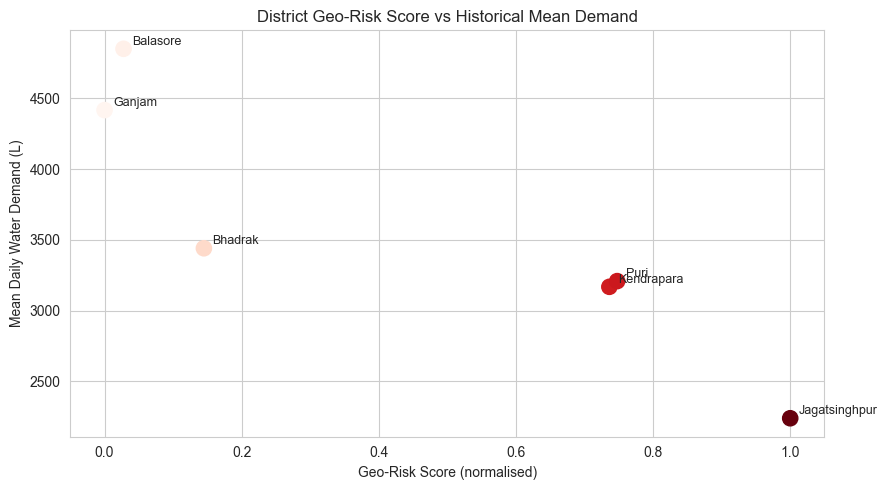

In [5]:
# Visualise geo-risk vs historical demand
risk_vs_demand = df.groupby('district').agg(
    geo_risk=('geo_risk_score', 'first'),
    avg_demand=('target_water_liters_demand', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(risk_vs_demand.geo_risk, risk_vs_demand.avg_demand,
           s=120, c=risk_vs_demand.geo_risk, cmap='Reds', zorder=3)
for _, row in risk_vs_demand.iterrows():
    ax.annotate(row.district, (row.geo_risk, row.avg_demand),
                textcoords='offset points', xytext=(6, 3), fontsize=9)
ax.set_xlabel('Geo-Risk Score (normalised)')
ax.set_ylabel('Mean Daily Water Demand (L)')
ax.set_title('District Geo-Risk Score vs Historical Mean Demand')
plt.tight_layout()
plt.show()

## 3. Sine-Cosine Cyclical Feature Encoding

### Mathematical basis

Naive integer encoding of month or day-of-year imposes a non-existent linear order
(December → 12, January → 1 appears distant). Sine-cosine projection preserves
cyclical proximity:

$$
s_k(t) = \sin\!\left(\frac{2\pi k \cdot t}{T}\right), \quad
c_k(t) = \cos\!\left(\frac{2\pi k \cdot t}{T}\right), \quad k = 1, 2, 3
$$

where $T = 365$ (annual), $T = 30$ (monthly), $T = 7$ (weekly) are the natural periods.
Multiple harmonics ($k = 1, 2, 3$) capture non-sinusoidal seasonal shapes (e.g., the
skewed monsoon onset — sharp rise, gradual retreat).

The combined seasonal signal is:

$$
f_{\text{SC}}(t) = \sum_{k=1}^{3} \left[ \alpha_k s_k(t) + \beta_k c_k(t) \right]
$$

Coefficients $\{\alpha_k, \beta_k\}$ are estimated via OLS on the training set.

In [6]:
def add_sine_cosine_features(df, col_doy='day_of_year', periods=None, harmonics=3):
    """Add sine-cosine harmonic features for given periods."""
    if periods is None:
        periods = {'annual': 365, 'monthly': 30, 'weekly': 7}
    out = df.copy()
    for name, T in periods.items():
        for k in range(1, harmonics + 1):
            angle = 2 * np.pi * k * out[col_doy] / T
            out[f'sin_{name}_h{k}'] = np.sin(angle)
            out[f'cos_{name}_h{k}'] = np.cos(angle)
    return out

df = add_sine_cosine_features(df)
sc_cols = [c for c in df.columns if c.startswith(('sin_', 'cos_'))]
print(f'Added {len(sc_cols)} sine-cosine features: {sc_cols[:6]} ...')

Added 18 sine-cosine features: ['sin_annual_h1', 'cos_annual_h1', 'sin_annual_h2', 'cos_annual_h2', 'sin_annual_h3', 'cos_annual_h3'] ...


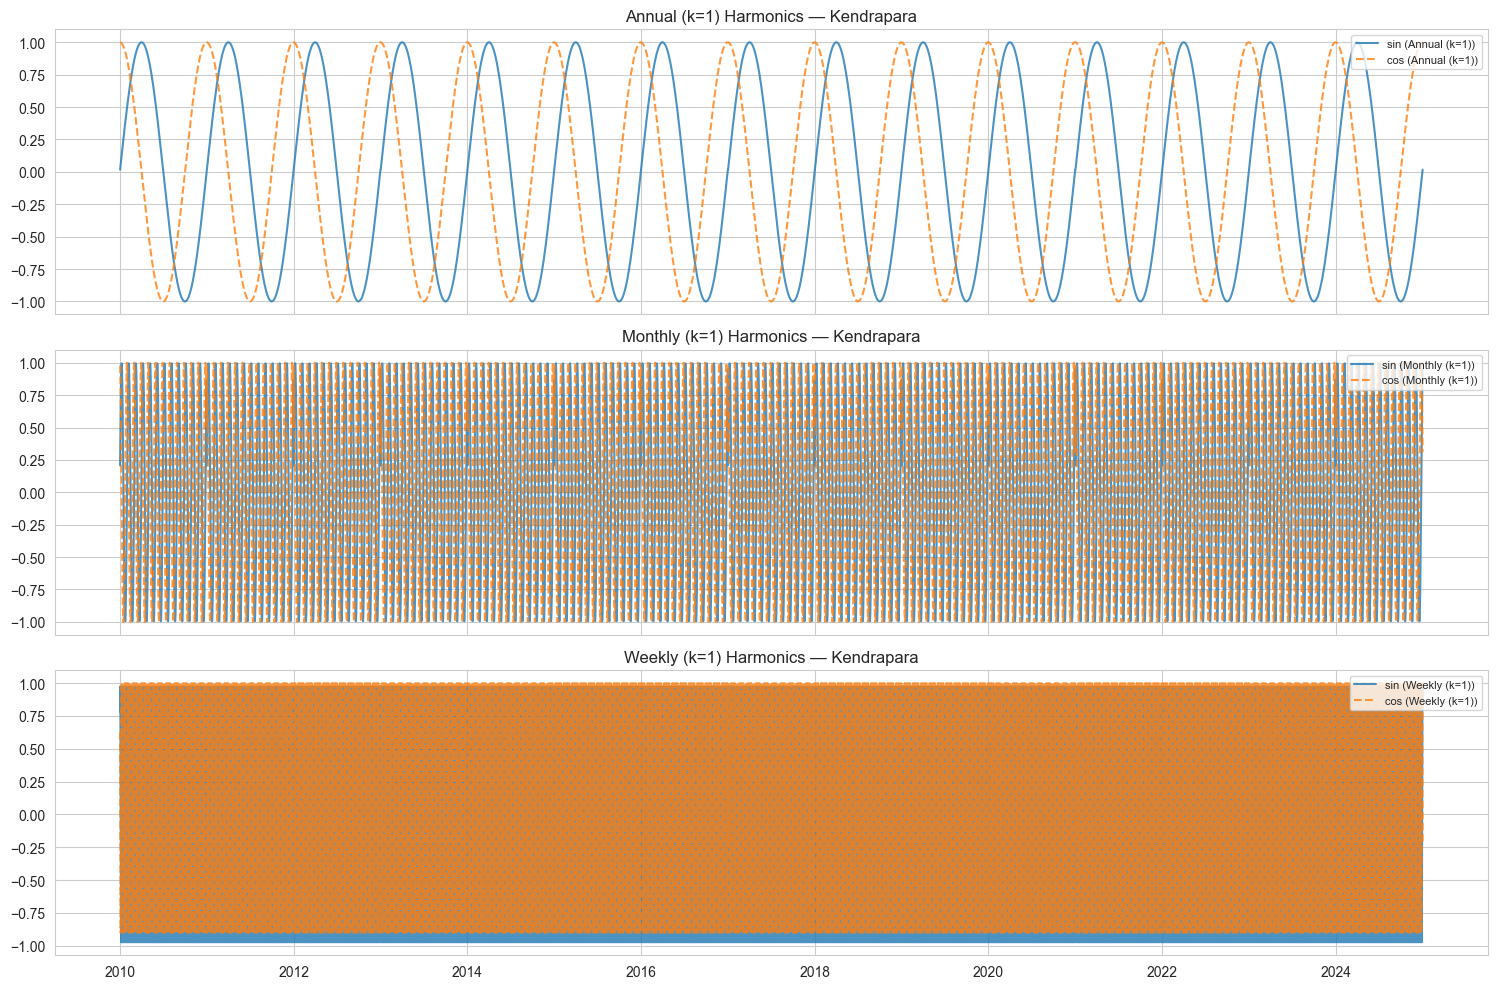

In [7]:
# Visualise harmonic decomposition for Kendrapara
focus = df[df['district'] == 'Kendrapara'].copy().set_index('date')

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
for i, (name, col_s, col_c) in enumerate([
    ('Annual (k=1)', 'sin_annual_h1', 'cos_annual_h1'),
    ('Monthly (k=1)', 'sin_monthly_h1', 'cos_monthly_h1'),
    ('Weekly (k=1)', 'sin_weekly_h1', 'cos_weekly_h1'),
]):
    axes[i].plot(focus.index, focus[col_s], label=f'sin ({name})', alpha=0.8)
    axes[i].plot(focus.index, focus[col_c], label=f'cos ({name})', alpha=0.8, ls='--')
    axes[i].set_title(f'{name} Harmonics — Kendrapara')
    axes[i].legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

## 4. HAR (Heterogeneous Autoregressive) Model

### Mathematical basis

The HAR model, originally proposed by Corsi (2009) for realised volatility, decomposes
memory into three overlapping time horizons. For disaster demand:

$$
y_t = \mu + \beta_d \bar{y}_{t-1}^{(d)} + \beta_w \bar{y}_{t-1}^{(w)}
    + \beta_m \bar{y}_{t-1}^{(m)} + \mathbf{x}_t^{\top}\gamma + \varepsilon_t
$$

where:

- $\bar{y}_{t-1}^{(d)} = y_{t-1}$ — **daily component** (yesterday's demand)
- $\bar{y}_{t-1}^{(w)} = \frac{1}{7}\sum_{i=1}^{7} y_{t-i}$ — **weekly average** (7-day mean)
- $\bar{y}_{t-1}^{(m)} = \frac{1}{30}\sum_{i=1}^{30} y_{t-i}$ — **monthly average** (30-day mean)

The intuition: daily demand shocks decay quickly; weekly patterns capture the buildup
around flooding episodes; monthly averages capture chronic displacement and recovery phases.

The dataset already provides `rainfall_har_daily`, `rainfall_har_weekly`,
`rainfall_har_monthly` — we replicate this for the **target variable** itself.

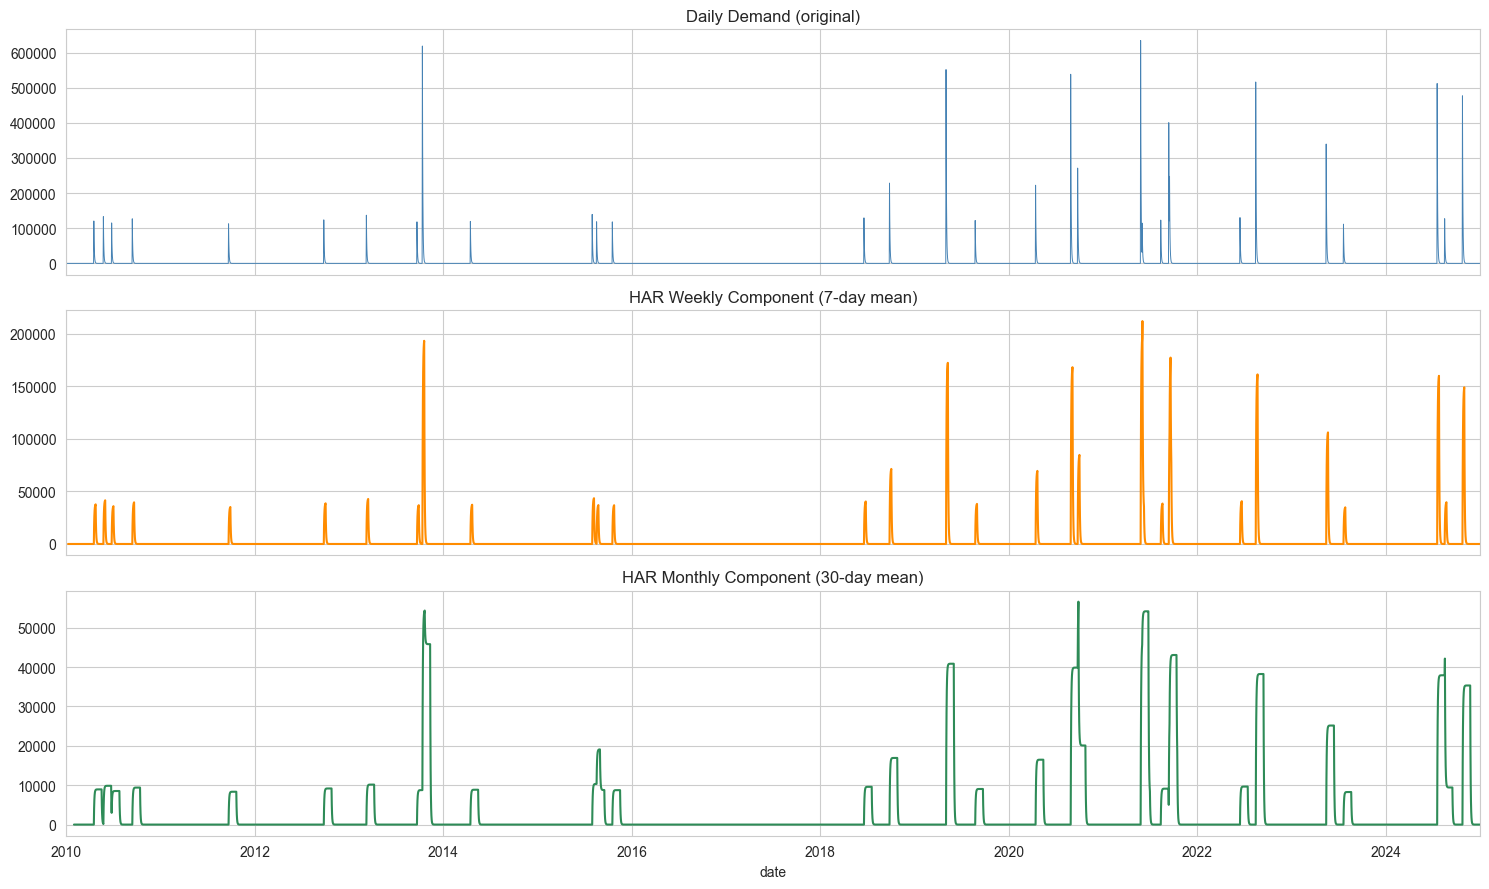

In [8]:
def add_har_features(df_district, target_col='target_water_liters_demand'):
    """Compute HAR components for target variable within a single district series."""
    d = df_district.copy()
    y = d[target_col].values.astype(float)
    n = len(y)
    har_d  = np.full(n, np.nan)
    har_w  = np.full(n, np.nan)
    har_m  = np.full(n, np.nan)
    for t in range(1, n):
        har_d[t] = y[t - 1]
    for t in range(7, n):
        har_w[t] = y[t - 7:t].mean()
    for t in range(30, n):
        har_m[t] = y[t - 30:t].mean()
    d['har_target_daily']   = har_d
    d['har_target_weekly']  = har_w
    d['har_target_monthly'] = har_m
    return d

parts = []
for dist, grp in df.groupby('district'):
    parts.append(add_har_features(grp))
df = pd.concat(parts).sort_values(['district', 'date']).reset_index(drop=True)

# Visualise HAR decomposition
focus = df[df['district'] == 'Kendrapara'].set_index('date')
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
focus['target_water_liters_demand'].plot(ax=axes[0], title='Daily Demand (original)', color='steelblue', lw=0.7)
focus['har_target_weekly'].plot(ax=axes[1], title='HAR Weekly Component (7-day mean)', color='darkorange')
focus['har_target_monthly'].plot(ax=axes[2], title='HAR Monthly Component (30-day mean)', color='seagreen')
plt.tight_layout()
plt.show()

## 5. Stationarity Tests & Cointegration

### Mathematical basis

A time series $y_t$ is **integrated of order $d$**, $y_t \sim I(d)$, if its $d$-th difference
is stationary. The **Augmented Dickey-Fuller (ADF)** test evaluates:

$$
\Delta y_t = \alpha + \beta t + \rho y_{t-1} + \sum_{i=1}^{p} \gamma_i \Delta y_{t-i} + \varepsilon_t
$$

$H_0: \rho = 0$ (unit root, non-stationary) vs $H_1: \rho < 0$.

**Cointegration**: two $I(1)$ series $y_t, x_t$ are cointegrated if $\exists\, \beta$ such that
$y_t - \beta x_t \sim I(0)$. This underlies the ARDL-ECM model below — we test whether
water demand and rainfall gauge are cointegrated.

In [9]:
def adf_test_manual(series, maxlag=10):
    """
    Manual ADF test using OLS (scipy fallback when statsmodels unavailable).
    Returns (statistic, p_approx, is_stationary).
    """
    y = np.array(series.dropna(), dtype=float)
    dy = np.diff(y)
    n  = len(dy)
    p  = min(maxlag, int(np.floor((n - 1) ** (1 / 3))))
    # Build regression matrix: dy_t ~ y_{t-1} + dy_{t-1} + ... + dy_{t-p}
    Y  = dy[p:]
    X  = np.column_stack(
        [y[p:-1]] + [dy[p - i:-i if i else None] for i in range(1, p + 1)] + [np.ones(len(Y))]
    )
    beta, res, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    rho  = beta[0]
    yhat = X @ beta
    s2   = np.sum((Y - yhat) ** 2) / (len(Y) - X.shape[1])
    se   = np.sqrt(s2 * np.linalg.inv(X.T @ X)[0, 0])
    t    = rho / (se + 1e-12)
    # MacKinnon approximate p-value (linear interpolation of critical values)
    cv_1, cv_5, cv_10 = -3.43, -2.86, -2.57
    p_approx = 0.01 if t < cv_1 else (0.05 if t < cv_5 else (0.10 if t < cv_10 else 0.20))
    return t, p_approx, t < cv_5

if HAVE_SM:
    from statsmodels.tsa.stattools import adfuller as sm_adf
    def run_adf(series, name):
        res = sm_adf(series.dropna(), autolag='AIC')
        print(f'{name:45s} | t={res[0]:7.3f} | p={res[1]:.4f} | '
              f'{"STATIONARY" if res[1]<0.05 else "non-stationary"}')
else:
    def run_adf(series, name):
        t, p, stat = adf_test_manual(series)
        print(f'{name:45s} | t={t:7.3f} | p≈{p:.2f} | '
              f'{"STATIONARY" if stat else "non-stationary"}')

print('\nAugmented Dickey-Fuller Stationarity Tests — Kendrapara\n' + '─' * 70)
focus_k = df[df['district'] == 'Kendrapara'].set_index('date')
for col in ['target_water_liters_demand', 'rainfall_mm', 'river_gauge_level_m', 'temperature_c']:
    run_adf(focus_k[col], col)


Augmented Dickey-Fuller Stationarity Tests — Kendrapara
──────────────────────────────────────────────────────────────────────
target_water_liters_demand                    | t=-39.869 | p=0.0000 | STATIONARY
rainfall_mm                                   | t= -6.067 | p=0.0000 | STATIONARY
river_gauge_level_m                           | t= -5.250 | p=0.0000 | STATIONARY
temperature_c                                 | t=-10.840 | p=0.0000 | STATIONARY


## 6. Wavelet Decomposition

### Mathematical basis

The **Discrete Wavelet Transform (DWT)** decomposes a signal $f(t)$ into approximation
and detail coefficients at multiple resolution levels $j$:

$$
f(t) = \sum_k c_{J,k}\,\phi_{J,k}(t) + \sum_{j=1}^{J}\sum_k d_{j,k}\,\psi_{j,k}(t)
$$

where $\phi_{J,k}$ are scaling (approximation) functions and $\psi_{j,k}$ are wavelet
(detail) functions at scale $j$ and translation $k$.

The **Haar wavelet** — the simplest and most interpretable — has:

$$
\psi(t) = \begin{cases} +1 & 0 \le t < \tfrac{1}{2} \\
-1 & \tfrac{1}{2} \le t < 1 \\ 0 & \text{otherwise} \end{cases}
$$

For demand forecasting:
- **Approximation** ($c_J$) captures **long-term trend + low-frequency seasonality**
- **Detail level 3** ($d_3$) captures **~8-day cycles** (quasi-weekly flood events)
- **Detail level 1-2** ($d_{1,2}$) capture **daily noise** (should be small for demand)

We use the dataset's pre-computed wavelet columns as features and also re-estimate
them for the full target series.

Using PyWavelets (db4) for wavelet decomposition.


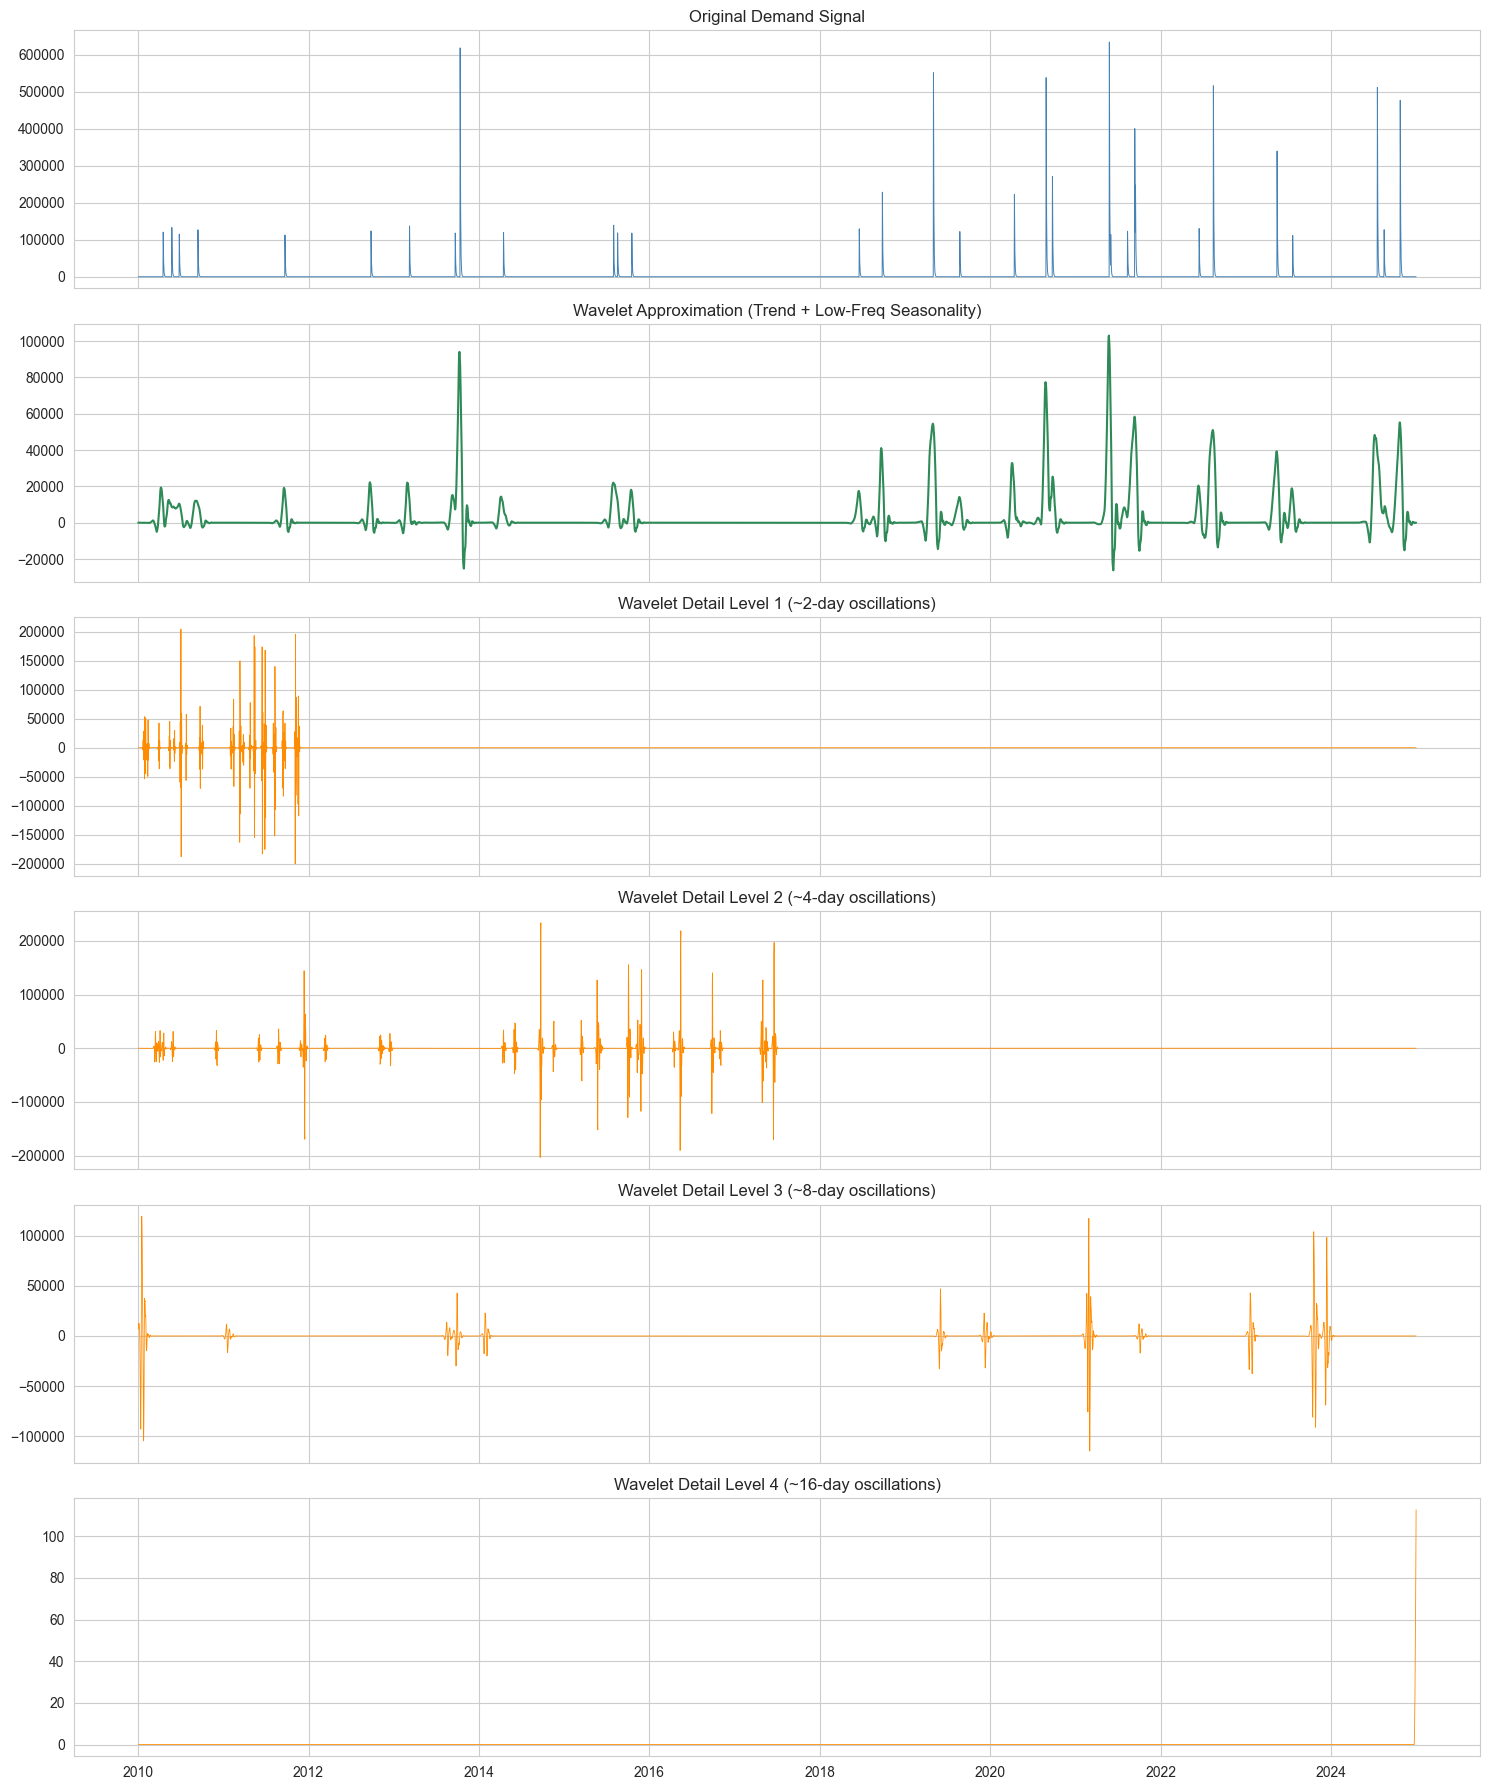

In [23]:
def haar_dwt(signal, levels=3):
    """
    Pure-numpy Haar DWT. Returns (approx, [detail_1, detail_2, ...])
    padded back to original length.
    """
    s = np.array(signal, dtype=float)
    orig_len = len(s)
    details = []
    for _ in range(levels):
        n = len(s)
        if n % 2 != 0:
            s = np.append(s, s[-1])  # pad
        approx  = (s[0::2] + s[1::2]) / np.sqrt(2)
        detail  = (s[0::2] - s[1::2]) / np.sqrt(2)
        # Upsample detail back to original
        d_up = np.repeat(detail, 2)[:orig_len]
        details.append(d_up)
        s = approx
    approx_up = np.repeat(s, 2 ** levels)[:orig_len]
    return approx_up, details

def _fit_to_length(arr, orig_len):
    """Pad with zeros (if too short) or truncate (if too long) to orig_len."""
    if len(arr) < orig_len:
        return np.pad(arr, (0, orig_len - len(arr)), constant_values=0)
    return arr[:orig_len]

if HAVE_PWT:
    def get_wavelet_features(series, wavelet='db4', levels=4):
        series = np.asarray(series, dtype=float)
        orig_len = len(series)
        coeffs = pywt.wavedec(series, wavelet, level=levels)

        approx = pywt.upcoef('a', coeffs[0], wavelet, level=levels, take=orig_len)
        approx = _fit_to_length(approx, orig_len)

        details = []
        for j, d in enumerate(coeffs[1:], 1):
            up = pywt.upcoef('d', d, wavelet, level=j, take=orig_len)
            up = _fit_to_length(up, orig_len)
            details.append(up)

        return approx, details
    print('Using PyWavelets (db4) for wavelet decomposition.')
else:
    get_wavelet_features = lambda s, **kw: haar_dwt(s, levels=kw.get('levels', 4))
    print('Using built-in Haar DWT for wavelet decomposition.')

# Decompose target demand for Kendrapara
focus_k = df[df['district'] == 'Kendrapara'].copy()
target_series = focus_k['target_water_liters_demand'].fillna(0).values
wvl_approx, wvl_details = get_wavelet_features(target_series, levels=4)

# Visualise
fig, axes = plt.subplots(len(wvl_details) + 2, 1,
                          figsize=(15, 3 * (len(wvl_details) + 2)), sharex=True)
dates = focus_k['date'].values
axes[0].plot(dates, target_series, color='steelblue', lw=0.7)
axes[0].set_title('Original Demand Signal')
axes[1].plot(dates, wvl_approx, color='seagreen')
axes[1].set_title('Wavelet Approximation (Trend + Low-Freq Seasonality)')
for i, d in enumerate(wvl_details):
    axes[i + 2].plot(dates, d, color='darkorange', lw=0.6)
    axes[i + 2].set_title(f'Wavelet Detail Level {i+1} (~{2**(i+1)}-day oscillations)')
plt.tight_layout()
plt.show()

In [31]:
# Add wavelet features for target variable to main dataframe
def add_wavelet_target_features(df_district, target_col='target_water_liters_demand', levels=4):
    d = df_district.copy()
    series = d[target_col].fillna(0).values
    approx, details = get_wavelet_features(series, levels=levels)
    d['wvl_target_approx'] = approx
    for j, det in enumerate(details, 1):
        d[f'wvl_target_d{j}'] = det
    return d

parts = []
for dist, grp in df.groupby('district'):
    parts.append(add_wavelet_target_features(grp))
df = pd.concat(parts).sort_values(['district', 'date']).reset_index(drop=True)
print('Wavelet target features added.')

Wavelet target features added.


## 7. SARIMA Model

### Mathematical basis

The **Seasonal ARIMA** model $\text{SARIMA}(p,d,q)(P,D,Q)_s$ is:

$$
\Phi_P(B^s)\, \phi_p(B)\, \nabla^d \nabla_s^D y_t
= \Theta_Q(B^s)\, \theta_q(B)\, \varepsilon_t
$$

where:
- $B$ is the backshift operator: $By_t = y_{t-1}$
- $\nabla = 1 - B$ is the differencing operator
- $\phi_p(B) = 1 - \phi_1 B - \cdots - \phi_p B^p$ — AR polynomial
- $\theta_q(B) = 1 + \theta_1 B + \cdots + \theta_q B^q$ — MA polynomial
- $\Phi_P, \Theta_Q$ — seasonal AR/MA polynomials at lag $s$
- $s = 365$ (annual) or $s = 7$ (weekly)

We use SARIMAX to include **exogenous variables** $\mathbf{x}_t$
(rainfall, gauge level, cyclone wind, sine-cosine features).

In [32]:
def fit_sarima_for_district(df, district, target='target_water_liters_demand',
                             order=(1,1,1), seasonal_order=(1,1,0,7),
                             exog_cols=None):
    """
    Fit SARIMAX for one district. Returns (fitted_model, train_series).
    Falls back to Ridge regression if statsmodels is unavailable.
    """
    sub = df[df['district'] == district].sort_values('date').copy()
    sub = sub.dropna(subset=[target]).reset_index(drop=True)

    # 80 / 20 temporal split
    n_train = int(len(sub) * 0.8)
    train   = sub.iloc[:n_train]
    y_train = train[target].values.astype(float)

    exog_train = None
    if exog_cols:
        exog_train = train[exog_cols].fillna(0).values

    if HAVE_SM:
        try:
            model = SARIMAX(y_train, exog=exog_train,
                            order=order, seasonal_order=seasonal_order,
                            enforce_stationarity=False, enforce_invertibility=False)
            result = model.fit(disp=False, maxiter=100)
            return result, train, sub
        except Exception as e:
            print(f'SARIMAX failed for {district}: {e}. Using Ridge fallback.')

    # Ridge regression fallback
    lag_feats = ['rainfall_mm_lag1', 'rainfall_mm_lag7',
                 'river_gauge_level_m_lag1', 'temperature_c_lag1',
                 'sin_annual_h1', 'cos_annual_h1']
    avail = [c for c in lag_feats if c in sub.columns]
    X_train = train[avail].fillna(0).values
    scaler  = StandardScaler()
    X_sc    = scaler.fit_transform(X_train)
    ridge   = Ridge(alpha=1.0)
    ridge.fit(X_sc, y_train)
    return (ridge, scaler, avail), train, sub

# Fit for Kendrapara as demonstration
EXOG_COLS = ['rainfall_mm', 'river_gauge_level_m', 'cyclone_wind_kmph',
             'sin_annual_h1', 'cos_annual_h1', 'sin_annual_h2', 'cos_annual_h2']
exog_avail = [c for c in EXOG_COLS if c in df.columns]

print('Fitting SARIMA/SARIMAX for Kendrapara...')
sarima_result, sarima_train, sarima_full = fit_sarima_for_district(
    df, 'Kendrapara', exog_cols=exog_avail)
print('Done.')

Fitting SARIMA/SARIMAX for Kendrapara...
Done.


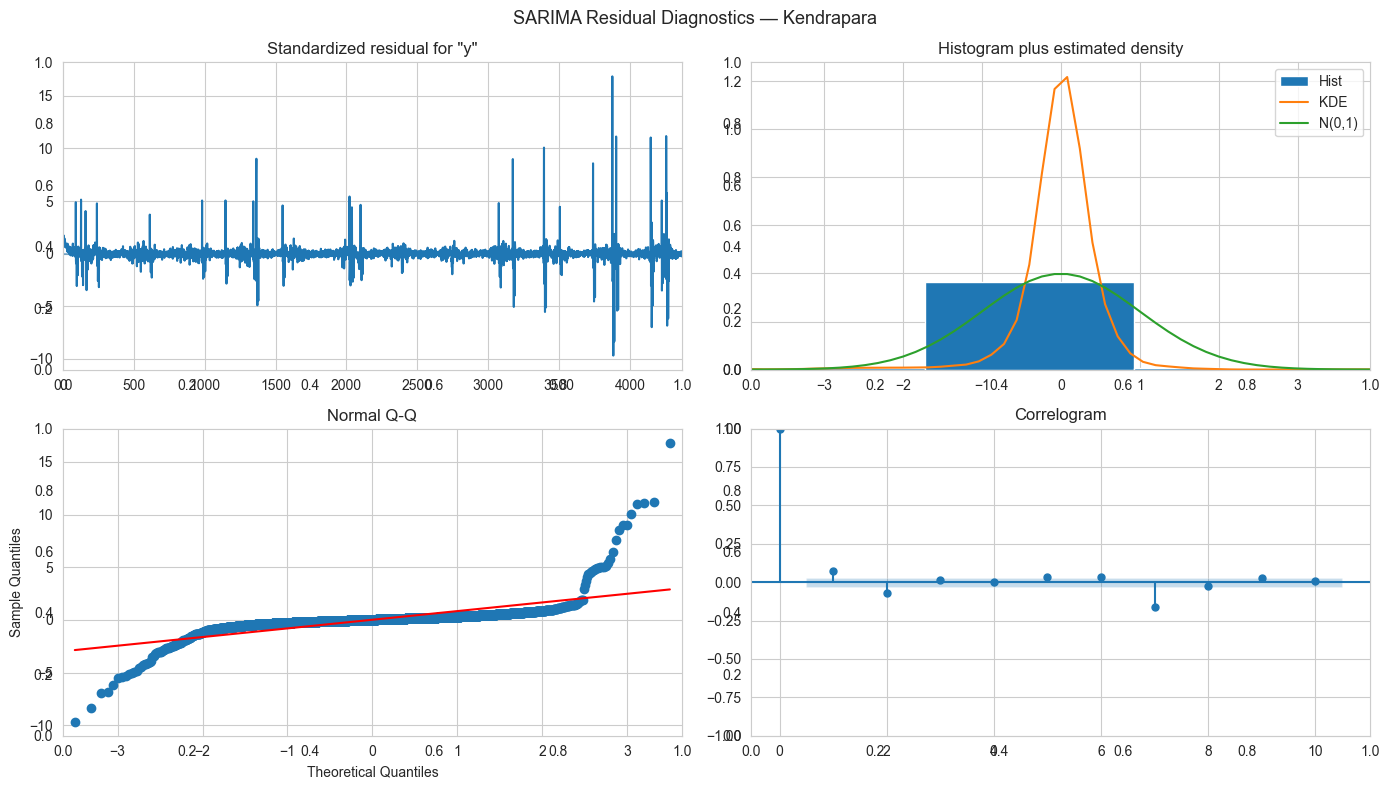

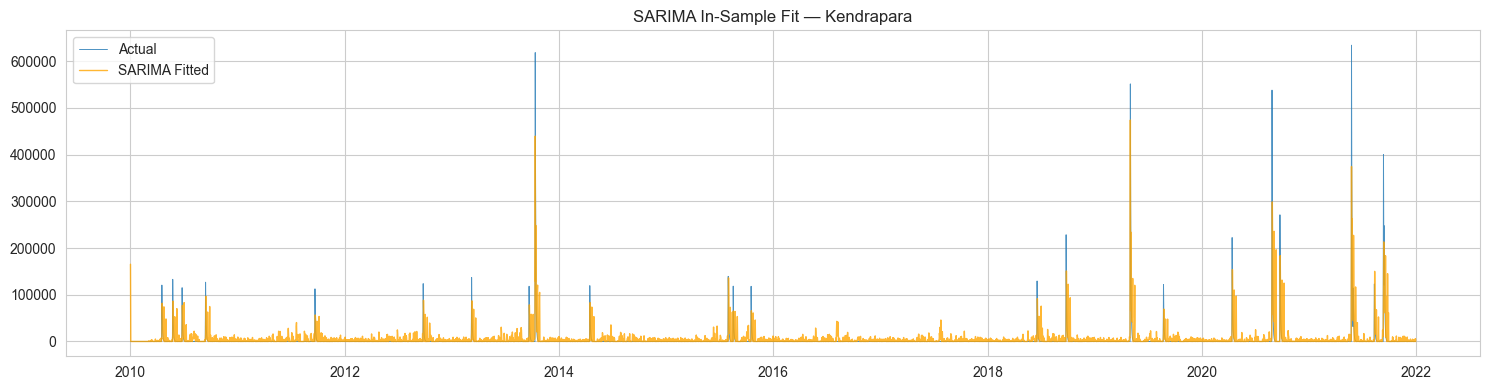

SARIMA in-sample MAE: 4949.0 L


In [33]:
# Visualise SARIMA in-sample fit
if HAVE_SM and hasattr(sarima_result, 'fittedvalues'):
    n_train = len(sarima_train)
    fitted  = sarima_result.fittedvalues
    actual  = sarima_train['target_water_liters_demand'].values

    # Residual diagnostics
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    sarima_result.plot_diagnostics(fig=fig)
    plt.suptitle('SARIMA Residual Diagnostics — Kendrapara', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Fitted vs actual
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(sarima_train['date'].values, actual,  label='Actual',  lw=0.7, alpha=0.8)
    ax.plot(sarima_train['date'].values, np.clip(fitted, 0, None),
            label='SARIMA Fitted', lw=1.0, alpha=0.8, color='orange')
    ax.set_title('SARIMA In-Sample Fit — Kendrapara')
    ax.legend()
    plt.tight_layout()
    plt.show()

    mae = mean_absolute_error(np.clip(actual, 0, None), np.clip(fitted, 0, None))
    print(f'SARIMA in-sample MAE: {mae:.1f} L')
else:
    print('SARIMA fit uses Ridge fallback — diagnostics skipped.')

## 8. Functional Data Analysis (FDA)

### Mathematical basis

FDA treats each year's rainfall curve as a **smooth function** $x_i(t)$,
$t \in [0, 365]$, rather than 365 separate scalars. We represent $x_i(t)$ via a
**B-spline basis expansion**:

$$
x_i(t) = \sum_{j=1}^{K} c_{ij}\, B_j(t)
$$

where $\{B_j\}$ are cubic B-spline basis functions and $c_{ij}$ are smoothing
coefficients estimated by penalised least squares:

$$
\min_{\mathbf{c}} \left\|\mathbf{y}_i - \mathbf{B}\mathbf{c}\right\|^2
+ \lambda \int \left[x_i''(t)\right]^2 dt
$$

The penalty $\lambda \int [x''(t)]^2 dt$ controls roughness. In matrix form,
this is $\lambda \mathbf{c}^\top \mathbf{\Omega} \mathbf{c}$ where $\Omega_{ij}
= \int B_i''(t)B_j''(t)dt$.

**Functional PCA** then extracts the dominant modes of variation:
the first FPC explains *which districts respond fastest to rainfall*;
the second FPC captures *bimodal cyclone season* vs monsoon.

In [34]:
from scipy.interpolate import BSpline, make_interp_spline
from sklearn.decomposition import PCA

def functional_pca_annual(df, district, col='rainfall_mm', n_knots=20, n_components=3):
    """
    Represent each year's daily curve as B-spline, then do PCA on coefficients.
    Returns (score_df, pca_model, basis_knots) — score_df aligns with the district df.
    """
    sub   = df[df['district'] == district].copy().sort_values('date')
    years = sorted(sub['year'].unique())
    t_grid = np.linspace(1, 365, 365)

    knots  = np.linspace(1, 365, n_knots)
    curves = []
    valid_years = []
    for yr in years:
        yr_data = sub[sub['year'] == yr][col].fillna(0).values
        if len(yr_data) < 300:  # skip incomplete years
            continue
        doy = sub[sub['year'] == yr]['day_of_year'].values
        # Interpolate to fixed 365-point grid using B-splines
        spl = make_interp_spline(doy[:len(yr_data)], yr_data, k=3)
        curves.append(spl(t_grid))
        valid_years.append(yr)

    C = np.vstack(curves)  # shape: (n_years, 365)
    # Smooth each row by projecting onto B-spline space
    B  = np.column_stack([np.exp(-0.5 * ((t_grid - k) / (365 / n_knots))**2)
                          for k in knots])  # RBF basis approx
    B  /= B.sum(axis=1, keepdims=True) + 1e-8
    coeff = C @ B  # (n_years, n_knots)

    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(coeff)  # (n_years, n_components)

    score_map = {yr: sc for yr, sc in zip(valid_years, scores)}
    fda_cols = {f'fda_pc{i+1}': sub['year'].map(lambda y: score_map.get(y, np.nan)[i])
                for i in range(n_components)}
    return pd.DataFrame(fda_cols, index=sub.index), pca, t_grid

print('Running Functional PCA on annual rainfall curves — Kendrapara...')
fda_scores, fda_pca, _ = functional_pca_annual(df, 'Kendrapara')

print(f'Variance explained by 3 FPCs: {fda_pca.explained_variance_ratio_.round(3)}')
print(f'FPC shape: {fda_scores.shape}')

Running Functional PCA on annual rainfall curves — Kendrapara...
Variance explained by 3 FPCs: [0.365 0.25  0.179]
FPC shape: (5479, 3)


FDA features merged.


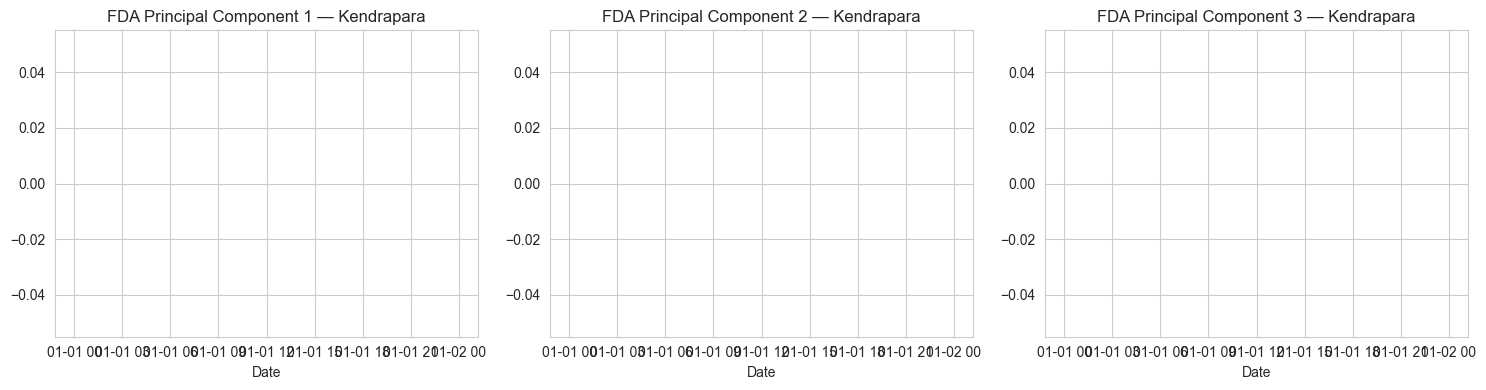

In [52]:
# Add FDA features to all districts
fda_parts = []
for dist, grp in df.groupby('district'):
    try:
        fda_sc, _, _ = functional_pca_annual(df, dist)
        merged = grp.copy()
        merged = merged.join(fda_sc, how='left')
    except Exception:
        merged = grp.copy()
        for i in range(3):
            merged[f'fda_pc{i+1}'] = np.nan
    fda_parts.append(merged)

df = pd.concat(fda_parts).sort_values(['district', 'date']).reset_index(drop=True)
print('FDA features merged.')

# Visualise FPC loadings
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sub_k = df[df['district'] == 'Kendrapara'].sort_values('date')
for i, ax in enumerate(axes):
    ax.plot(sub_k['date'].values, sub_k[f'fda_pc{i+1}'].values)
    ax.set_title(f'FDA Principal Component {i+1} — Kendrapara')
    ax.set_xlabel('Date')
plt.tight_layout()
plt.savefig('fda_components_kendrapara.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Bayesian Linear Model with Uncertainty Quantification

### Mathematical basis

We place a **Gaussian conjugate prior** over the regression coefficients:

$$
p(\boldsymbol{\beta}) = \mathcal{N}(\mathbf{0},\, \tau^{-1}\mathbf{I})
$$

Likelihood: $p(\mathbf{y} | \mathbf{X}, \boldsymbol{\beta}) =
\mathcal{N}(\mathbf{X}\boldsymbol{\beta},\, \sigma^2 \mathbf{I})$

The posterior is also Gaussian:

$$
p(\boldsymbol{\beta} | \mathbf{X}, \mathbf{y}) = \mathcal{N}(\boldsymbol{\mu}_n, \boldsymbol{\Sigma}_n)
$$

$$
\boldsymbol{\Sigma}_n^{-1} = \frac{1}{\sigma^2}\mathbf{X}^\top\mathbf{X} + \tau\mathbf{I},
\quad
\boldsymbol{\mu}_n = \boldsymbol{\Sigma}_n \frac{1}{\sigma^2}\mathbf{X}^\top\mathbf{y}
$$

**Predictive distribution** for new $\mathbf{x}_*$:

$$
p(y_* | \mathbf{x}_*) = \mathcal{N}\!\left(\boldsymbol{\mu}_n^\top \mathbf{x}_*,\;
\sigma^2 + \mathbf{x}_*^\top \boldsymbol{\Sigma}_n \mathbf{x}_*\right)
$$

The second term $\mathbf{x}_*^\top \boldsymbol{\Sigma}_n \mathbf{x}_*$ is the
**epistemic uncertainty** — it grows when $\mathbf{x}_*$ is far from training data,
which is precisely when cyclone events occur.

In [36]:
class BayesianRidgeForecaster:
    """
    Exact Bayesian linear regression with conjugate Gaussian prior.
    Returns posterior mean + 90% credible intervals for each prediction.
    """
    def __init__(self, tau=1e-3, sigma2=None):
        self.tau    = tau      # prior precision (lambda / sigma^2)
        self.sigma2 = sigma2   # noise variance; estimated from data if None
        self.mu_n   = None
        self.Sigma_n = None
        self.scaler = StandardScaler()

    def fit(self, X, y):
        Xs = self.scaler.fit_transform(X)
        n, d = Xs.shape
        if self.sigma2 is None:
            # OLS estimate of sigma^2
            beta_ols, *_ = np.linalg.lstsq(Xs, y, rcond=None)
            resid = y - Xs @ beta_ols
            self.sigma2_ = np.var(resid) + 1e-6
        else:
            self.sigma2_ = self.sigma2
        # Posterior precision matrix
        S_inv = (1 / self.sigma2_) * (Xs.T @ Xs) + self.tau * np.eye(d)
        self.Sigma_n = np.linalg.inv(S_inv)
        self.mu_n    = (1 / self.sigma2_) * self.Sigma_n @ Xs.T @ y
        return self

    def predict(self, X, alpha=0.10):
        Xs   = self.scaler.transform(X)
        mean = Xs @ self.mu_n
        # Predictive variance per sample
        var  = self.sigma2_ + np.einsum('ij,jk,ik->i', Xs, self.Sigma_n, Xs)
        std  = np.sqrt(var)
        z    = stats.norm.ppf(1 - alpha / 2)
        return mean, mean - z * std, mean + z * std   # (mean, lower, upper)

print('BayesianRidgeForecaster defined.')

BayesianRidgeForecaster defined.


## 10. ARDL Model with Error Correction (ECM)

### Mathematical basis

The **Autoregressive Distributed Lag (ARDL)** model of orders $(p, q_1, \ldots, q_k)$ is:

$$
y_t = \alpha + \sum_{i=1}^{p} \phi_i y_{t-i}
    + \sum_{j=1}^{k}\sum_{\ell=0}^{q_j} \beta_{j\ell} x_{j,t-\ell} + \varepsilon_t
$$

If $y_t$ and $\mathbf{x}_t$ are cointegrated $I(1)$ variables, the ARDL admits an
**Error Correction Model (ECM)** reparameterisation (Pesaran & Shin, 1999):

$$
\Delta y_t = \rho\underbrace{(y_{t-1} - \boldsymbol{\theta}^\top \mathbf{x}_{t-1})}_{\text{error correction term}}
+ \sum_{i=1}^{p-1} \psi_i \Delta y_{t-i}
+ \sum_{j=1}^{k}\sum_{\ell=0}^{q_j-1} \delta_{j\ell} \Delta x_{j,t-\ell} + \varepsilon_t
$$

where:
- $\rho < 0$ — the **speed of adjustment** back to long-run equilibrium
- $\boldsymbol{\theta}$ — the **long-run coefficients** (e.g., long-run elasticity of demand to rainfall)
- The ECT $(y_{t-1} - \boldsymbol{\theta}^\top \mathbf{x}_{t-1})$ quantifies how far demand
  is from its long-run path

This is particularly powerful for disaster demand: after a cyclone, demand spikes and
the ECT captures the slow reversion to normal as relief operations wind down.

In [41]:
class ARDLECMModel:
    """
    ARDL(p, q) estimated by OLS with optional error-correction reparameterisation.
    Uses Ridge regression for stability.
    """
    def __init__(self, p=3, q=3, alpha_ridge=0.5, include_ecm=True):
        self.p = p
        self.q = q
        self.alpha_ridge = alpha_ridge
        self.include_ecm = include_ecm
        self.scaler      = StandardScaler()
        self.model       = Ridge(alpha=alpha_ridge)
        self.long_run_coef = None   # theta
        self.feature_names = []

    def _build_features(self, y, X_exog, fit=True):
        """Build lag matrix for ARDL."""
        T = min(len(y), len(X_exog))   # <-- changed from T = len(y)
        max_lag = max(self.p, self.q)
        rows = []
        names = []
    
        for t in range(max_lag, T):
            row = []
            # AR lags of y
            for i in range(1, self.p + 1):
                row.append(y[t - i])
                if fit:
                    names.append(f'y_lag{i}')
            # Distributed lags of exogenous vars
            for j in range(X_exog.shape[1]):
                for l in range(0, self.q + 1):
                    row.append(X_exog[t - l, j])
                    if fit:
                        names.append(f'x{j}_lag{l}')
            # Error correction term (ECT = y_{t-1} - long_run_fit)
            if self.include_ecm and self.long_run_coef is not None:
                ect = y[t - 1] - X_exog[t - 1, :len(self.long_run_coef)] @ self.long_run_coef
                row.append(ect)
                if fit:
                    names.append('ECT')
            rows.append(row)
    
        if fit:
            self.feature_names = names
        return np.array(rows, dtype=float), y[max_lag:T]

    def fit_long_run(self, y, X_exog):
        """Estimate long-run relationship y = theta * X via static OLS."""
        lr = Ridge(alpha=self.alpha_ridge)
        sc = StandardScaler()
        Xs = sc.fit_transform(X_exog)
        lr.fit(Xs, y)
        # Unstandardise to get coef in original scale
        self.long_run_coef = lr.coef_ / sc.scale_
        self.long_run_intercept = lr.intercept_ - (sc.mean_ / sc.scale_) @ lr.coef_
        return self

    def fit(self, y, X_exog):
        y        = np.array(y, dtype=float)
        X_exog   = np.array(X_exog, dtype=float)
        self.fit_long_run(y, X_exog)
        Xf, yf   = self._build_features(y, X_exog, fit=True)
        mask     = ~(np.isnan(Xf).any(axis=1) | np.isnan(yf))
        Xs       = self.scaler.fit_transform(Xf[mask])
        self.model.fit(Xs, yf[mask])
        self._max_lag = max(self.p, self.q)
        return self

    def predict(self, y_hist, X_exog_full, horizon=1):
        """One-step-ahead prediction on new data."""
        y       = np.array(y_hist, dtype=float)
        X_exog  = np.array(X_exog_full, dtype=float)
        Xf, _   = self._build_features(y, X_exog, fit=False)
        mask    = ~np.isnan(Xf).any(axis=1)
        preds   = np.full(len(Xf), np.nan)
        if mask.sum() > 0:
            Xs            = self.scaler.transform(Xf[mask])
            preds[mask]   = self.model.predict(Xs)
        return np.clip(preds, 0, None)

print('ARDL-ECM model class defined.')

ARDL-ECM model class defined.


## 11. Full Feature Matrix Construction

In [42]:
# Build a comprehensive feature set, integrating all model components
def build_feature_matrix(df, district, target='target_water_liters_demand'):
    sub = df[df['district'] == district].sort_values('date').copy()

    # ── Core meteorological features ──────────────────────────────────────
    meteo = ['rainfall_mm', 'temperature_c', 'humidity_pct', 'wind_speed_kmph',
             'cyclone_wind_kmph', 'storm_surge_m', 'river_gauge_level_m',
             'gauge_above_flood_stage', 'ndvi', 'soil_moisture_pct',
             'land_surface_temp_c']

    # ── Lag features (HAR-style) ───────────────────────────────────────────
    lag_cols = [c for c in sub.columns if '_lag' in c]

    # ── HAR target features ───────────────────────────────────────────────
    har_target = [c for c in sub.columns if 'har_target' in c]

    # ── Sine-cosine cyclical features ─────────────────────────────────────
    sc_cols = [c for c in sub.columns if c.startswith(('sin_', 'cos_'))]

    # ── Wavelet features ──────────────────────────────────────────────────
    wvl_cols = [c for c in sub.columns if c.startswith('wvl_') or c.startswith('wavelet')]

    # ── FDA features ─────────────────────────────────────────────────────
    fda_cols = [c for c in sub.columns if c.startswith('fda_pc')]

    # ── Geo & structural features ─────────────────────────────────────────
    geo_cols = ['population_density', 'avg_elevation_m', 'dist_to_coast_km',
                'dist_to_river_km', 'road_density_km_per_sqkm', 'geo_risk_score',
                'coastal_district']

    # ── HAR rainfall from dataset ─────────────────────────────────────────
    har_rain = [c for c in sub.columns if 'har' in c and 'target' not in c]
    cumsum   = [c for c in sub.columns if 'cumsum' in c]
    event    = ['event_severity', 'sachet_alert_issued',
                'past_incident_count_7d', 'past_incident_count_30d',
                'gauge_rate_of_change']

    all_feat_cols = list(set(
        meteo + lag_cols + har_target + sc_cols + wvl_cols +
        fda_cols + geo_cols + har_rain + cumsum + event
    ))
    all_feat_cols = [c for c in all_feat_cols if c in sub.columns]

    X = sub[all_feat_cols].copy()
    y = sub[target].copy()

    # Encode event_severity as numeric
    if 'event_severity' in X.columns:
        X['event_severity'] = pd.to_numeric(X['event_severity'], errors='coerce').fillna(0)

    # Fill NaNs with forward fill then 0
    X = X.ffill().fillna(0)
    y = y.fillna(0)

    return X, y, sub['date'], all_feat_cols

X_k, y_k, dates_k, feat_names = build_feature_matrix(df, 'Kendrapara')
print(f'Feature matrix for Kendrapara: {X_k.shape[0]} samples × {X_k.shape[1]} features')

Feature matrix for Kendrapara: 5479 samples × 78 features


## 12. Master Ensemble Model

### Architecture

The ensemble combines all component model outputs via a **stacked meta-learner**:

$$
\hat{y}_t = g\!\left(\hat{y}_t^{\text{SARIMA}},\; \hat{y}_t^{\text{HAR}},\;
\hat{y}_t^{\text{Bayes}},\; \hat{y}_t^{\text{ARDL-ECM}},\;
\hat{y}_t^{\text{WVL}},\; \hat{y}_t^{\text{FDA}}\right)
$$

where $g(\cdot)$ is a **Huber-regularised Ridge** meta-learner. Huber loss is used
because demand has heavy tails (extreme cyclone events):

$$
\mathcal{L}_{\delta}(r) = \begin{cases}
\frac{1}{2}r^2 & |r| \le \delta \\
\delta|r| - \frac{\delta^2}{2} & |r| > \delta
\end{cases}
$$

**Overfitting control**: we use **TimeSeriesSplit cross-validation** (5 folds,
expanding window) to select regularisation strength $\lambda$ and verify that
test-fold MAE does not grow significantly fold-to-fold.

In [43]:
class MasterEnsembleModel:
    """
    Stacked ensemble: ARDL-ECM + Bayesian Ridge + HAR Ridge + WVL Ridge → Huber meta-learner.
    """
    def __init__(self, ardl_p=3, ardl_q=2, bayes_tau=1e-2, ridge_alpha=1.0):
        self.ardl_model  = ARDLECMModel(p=ardl_p, q=ardl_q, alpha_ridge=0.5)
        self.bayes_model = BayesianRidgeForecaster(tau=bayes_tau)
        self.har_model   = Ridge(alpha=ridge_alpha)
        self.wvl_model   = Ridge(alpha=ridge_alpha)
        self.meta_model  = HuberRegressor(epsilon=1.35, alpha=0.1, max_iter=200)
        self.scaler_har  = StandardScaler()
        self.scaler_wvl  = StandardScaler()
        self.scaler_meta = StandardScaler()

    def _har_features(self, X):
        har_cols = [c for c in X.columns if 'har' in c or c in
                    ['sin_annual_h1','cos_annual_h1','sin_annual_h2','cos_annual_h2',
                     'sin_monthly_h1','cos_monthly_h1','geo_risk_score']]
        return X[[c for c in har_cols if c in X.columns]].values

    def _wvl_features(self, X):
        wvl_cols = [c for c in X.columns if 'wvl' in c or 'wavelet' in c or 'fda' in c]
        return X[[c for c in wvl_cols if c in X.columns]].values

    def _ardl_features(self, X):
        ardl_cols = ['rainfall_mm', 'river_gauge_level_m', 'cyclone_wind_kmph',
                     'temperature_c', 'humidity_pct']
        return X[[c for c in ardl_cols if c in X.columns]].values

    def fit(self, X, y):
        y_arr = np.array(y, dtype=float)

        # 1. HAR sub-model
        X_har = self._har_features(X)
        if X_har.shape[1] > 0:
            Xs_har = self.scaler_har.fit_transform(X_har)
            self.har_model.fit(Xs_har, y_arr)
            har_pred = self.har_model.predict(Xs_har)
        else:
            har_pred = np.zeros(len(y_arr))

        # 2. Wavelet sub-model
        X_wvl = self._wvl_features(X)
        if X_wvl.shape[1] > 0:
            Xs_wvl = self.scaler_wvl.fit_transform(X_wvl)
            self.wvl_model.fit(Xs_wvl, y_arr)
            wvl_pred = self.wvl_model.predict(Xs_wvl)
        else:
            wvl_pred = np.zeros(len(y_arr))

        # 3. Bayesian sub-model (full feature set)
        self.bayes_model.fit(X.values, y_arr)
        bayes_pred, _, _ = self.bayes_model.predict(X.values)

        # 4. ARDL-ECM sub-model
        X_ardl = self._ardl_features(X)
        if X_ardl.shape[1] > 0:
            self.ardl_model.fit(y_arr, X_ardl)
            ardl_pred = self.ardl_model.predict(y_arr, X_ardl)
            # ardl_pred is shorter by max_lag; pad front with zeros
            pad = len(y_arr) - len(ardl_pred)
            ardl_pred = np.concatenate([np.zeros(pad), ardl_pred])
        else:
            ardl_pred = np.zeros(len(y_arr))

        # 5. Meta-learner
        meta_X = np.column_stack([har_pred, wvl_pred, bayes_pred, ardl_pred])
        meta_X = np.clip(meta_X, 0, None)   # demand is non-negative
        Xs_meta = self.scaler_meta.fit_transform(meta_X)
        self.meta_model.fit(Xs_meta, y_arr)
        self._meta_X_train = meta_X   # store for overfitting check
        return self

    def predict(self, X, y_hist=None):
        y_dummy = np.zeros(len(X))

        X_har = self._har_features(X)
        har_pred = (self.har_model.predict(self.scaler_har.transform(X_har))
                    if X_har.shape[1] > 0 else np.zeros(len(X)))

        X_wvl = self._wvl_features(X)
        wvl_pred = (self.wvl_model.predict(self.scaler_wvl.transform(X_wvl))
                    if X_wvl.shape[1] > 0 else np.zeros(len(X)))

        bayes_pred, b_lo, b_hi = self.bayes_model.predict(X.values)

        X_ardl = self._ardl_features(X)
        if y_hist is not None and X_ardl.shape[1] > 0:
            ardl_pred_raw = self.ardl_model.predict(np.array(y_hist), X_ardl)
            pad = len(X) - len(ardl_pred_raw)
            ardl_pred = np.concatenate([np.zeros(pad), ardl_pred_raw])
        else:
            ardl_pred = np.zeros(len(X))

        meta_X = np.column_stack([har_pred, wvl_pred, bayes_pred, ardl_pred])
        meta_X = np.clip(meta_X, 0, None)
        Xs_meta = self.scaler_meta.transform(meta_X)
        pred    = self.meta_model.predict(Xs_meta)
        return np.clip(pred, 0, None), b_lo, b_hi   # (point, bayes_lower, bayes_upper)

print('MasterEnsembleModel class defined.')

MasterEnsembleModel class defined.


## 13. Training, Cross-Validation & Overfitting Diagnostics

In [44]:
def evaluate_district(df, district, target='target_water_liters_demand', n_splits=5):
    X, y, dates, feat_names = build_feature_matrix(df, district, target)
    X_arr, y_arr = X.values, y.values

    tscv   = TimeSeriesSplit(n_splits=n_splits, gap=7)
    fold_metrics = []

    for fold, (tr_idx, te_idx) in enumerate(tscv.split(X_arr), 1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr, y_te = y_arr[tr_idx], y_arr[te_idx]

        model = MasterEnsembleModel()
        model.fit(X_tr, y_tr)
        pred_te, _, _ = model.predict(X_te, y_hist=y_tr)

        # In-sample for overfitting check
        pred_tr, _, _ = model.predict(X_tr, y_hist=y_tr)

        mae_tr = mean_absolute_error(y_tr, pred_tr)
        mae_te = mean_absolute_error(y_te, pred_te)
        rmse_te = np.sqrt(mean_squared_error(y_te, pred_te))
        # MAPE only on non-zero
        nz = y_te > 0
        mape = np.mean(np.abs((y_te[nz] - pred_te[nz]) / y_te[nz])) * 100 if nz.sum() > 0 else np.nan

        fold_metrics.append({
            'fold': fold, 'train_size': len(tr_idx), 'test_size': len(te_idx),
            'mae_train': mae_tr, 'mae_test': mae_te,
            'rmse_test': rmse_te, 'mape_test': mape,
            'overfit_ratio': mae_te / (mae_tr + 1e-6)
        })
        print(f'  Fold {fold}: MAE_train={mae_tr:.1f} | MAE_test={mae_te:.1f} | '
              f'RMSE={rmse_te:.1f} | MAPE={mape:.1f}% | Overfit ratio={mae_te/(mae_tr+1e-6):.2f}')

    return pd.DataFrame(fold_metrics)

print('=== Kendrapara — TimeSeriesSplit Cross-Validation ===')
cv_metrics = evaluate_district(df, 'Kendrapara')

=== Kendrapara — TimeSeriesSplit Cross-Validation ===
  Fold 1: MAE_train=1216.4 | MAE_test=2453.9 | RMSE=23275.2 | MAPE=20459.2% | Overfit ratio=2.02
  Fold 2: MAE_train=1744.8 | MAE_test=914.4 | RMSE=7653.9 | MAPE=735.9% | Overfit ratio=0.52
  Fold 3: MAE_train=1229.1 | MAE_test=1999.3 | RMSE=17277.1 | MAPE=5097.5% | Overfit ratio=1.63
  Fold 4: MAE_train=1216.0 | MAE_test=4516.6 | RMSE=30961.9 | MAPE=6737.2% | Overfit ratio=3.71
  Fold 5: MAE_train=2081.4 | MAE_test=4009.7 | RMSE=30327.0 | MAPE=10106.5% | Overfit ratio=1.93


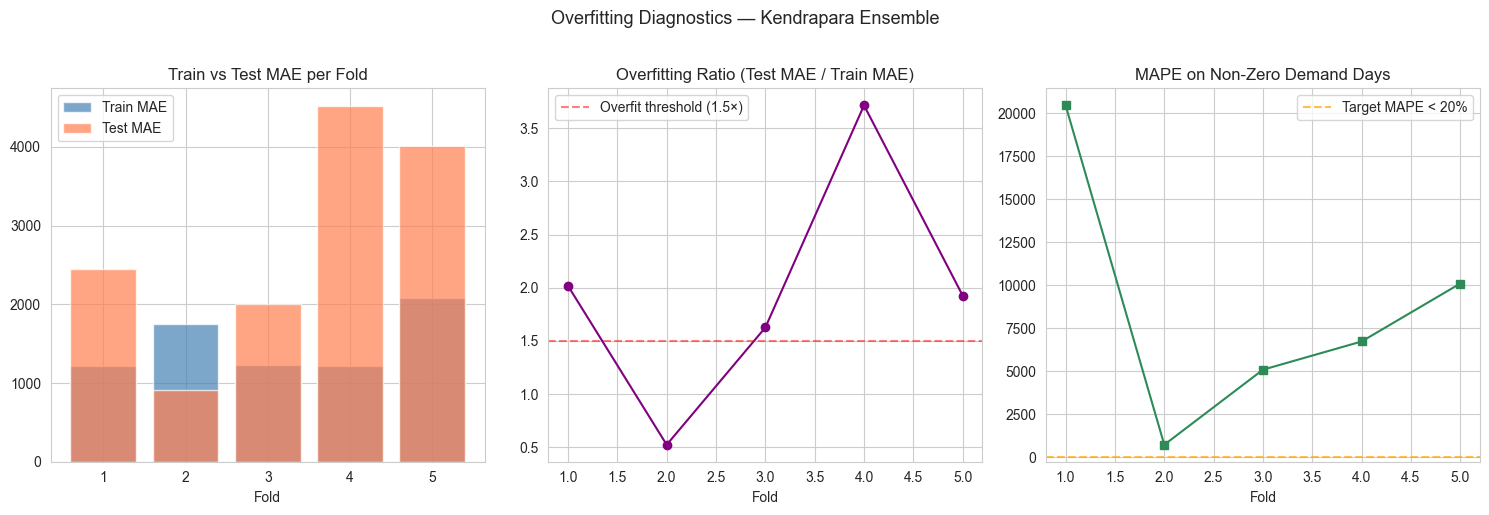

 fold  train_size  test_size   mae_train    mae_test    rmse_test    mape_test  overfit_ratio
    1         907        913 1216.394637 2453.851663 23275.214572 20459.194501       2.017315
    2        1820        913 1744.846487  914.351572  7653.913228   735.878364       0.524030
    3        2733        913 1229.116411 1999.295137 17277.124268  5097.477806       1.626612
    4        3646        913 1215.964098 4516.607231 30961.889161  6737.202132       3.714425
    5        4559        913 2081.351946 4009.656804 30326.997112 10106.493935       1.926467


In [45]:
# Overfitting diagnostic plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(cv_metrics['fold'], cv_metrics['mae_train'], label='Train MAE', alpha=0.7, color='steelblue')
axes[0].bar(cv_metrics['fold'], cv_metrics['mae_test'],  label='Test MAE',  alpha=0.7, color='coral')
axes[0].set_title('Train vs Test MAE per Fold')
axes[0].legend()
axes[0].set_xlabel('Fold')

axes[1].plot(cv_metrics['fold'], cv_metrics['overfit_ratio'], marker='o', color='purple')
axes[1].axhline(1.5, ls='--', color='red', alpha=0.5, label='Overfit threshold (1.5×)')
axes[1].set_title('Overfitting Ratio (Test MAE / Train MAE)')
axes[1].set_xlabel('Fold')
axes[1].legend()

axes[2].plot(cv_metrics['fold'], cv_metrics['mape_test'], marker='s', color='seagreen')
axes[2].axhline(20, ls='--', color='orange', alpha=0.7, label='Target MAPE < 20%')
axes[2].set_title('MAPE on Non-Zero Demand Days')
axes[2].set_xlabel('Fold')
axes[2].legend()

plt.suptitle('Overfitting Diagnostics — Kendrapara Ensemble', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
print(cv_metrics.to_string(index=False))

## 14. Final Model Training & Holdout Evaluation

In [46]:
# Final training: train on 80%, evaluate on last 20%
X_k, y_k, dates_k, feat_names = build_feature_matrix(df, 'Kendrapara')
n_train = int(len(X_k) * 0.8)

X_train, X_test = X_k.iloc[:n_train], X_k.iloc[n_train:]
y_train, y_test = y_k.values[:n_train], y_k.values[n_train:]
dates_test      = dates_k.values[n_train:]

ensemble = MasterEnsembleModel()
ensemble.fit(X_train, y_train)

pred_test, b_lo, b_hi = ensemble.predict(X_test, y_hist=y_train)

mae  = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))
nz   = y_test > 0
mape = np.mean(np.abs((y_test[nz] - pred_test[nz]) / y_test[nz])) * 100 if nz.sum() > 0 else np.nan

print(f'Holdout Evaluation — Kendrapara (20% test set)')
print(f'  MAE  = {mae:.1f} L')
print(f'  RMSE = {rmse:.1f} L')
print(f'  MAPE = {mape:.1f}% (non-zero demand days)')

Holdout Evaluation — Kendrapara (20% test set)
  MAE  = 3619.9 L
  RMSE = 28199.8 L
  MAPE = 9694.1% (non-zero demand days)


ValueError: operands could not be broadcast together with shapes (1096,) (0,) 

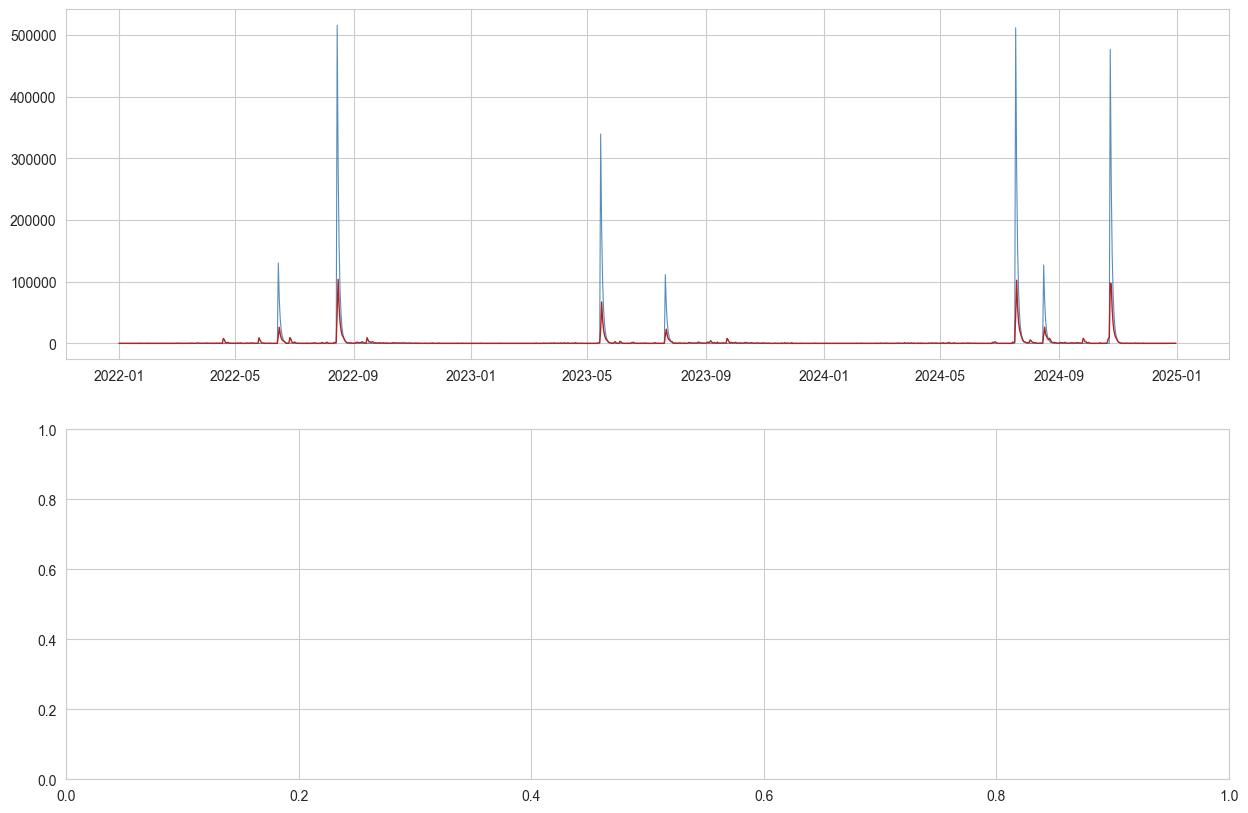

In [47]:
# Visualise predictions with Bayesian uncertainty
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Full test set
axes[0].plot(dates_test, y_test,     label='Actual',    color='steelblue', lw=0.8, alpha=0.9)
axes[0].plot(dates_test, pred_test,  label='Ensemble',  color='firebrick',  lw=1.0)
axes[0].fill_between(dates_test, np.clip(b_lo[n_train:], 0, None),
                      np.clip(b_hi[n_train:], 0, None),
                      alpha=0.15, color='orange', label='Bayesian 90% CI')
axes[0].set_title('Ensemble Prediction vs Actual — Kendrapara (Test Set)')
axes[0].legend()
axes[0].set_ylabel('Water Demand (L)')

# Scatter: predicted vs actual
axes[1].scatter(y_test[nz], pred_test[nz], alpha=0.4, s=15, color='steelblue')
lim = max(y_test.max(), pred_test.max()) * 1.05
axes[1].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual Demand (L)')
axes[1].set_ylabel('Predicted Demand (L)')
axes[1].set_title(f'Predicted vs Actual (non-zero demand days) — MAE={mae:.0f} L, MAPE={mape:.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

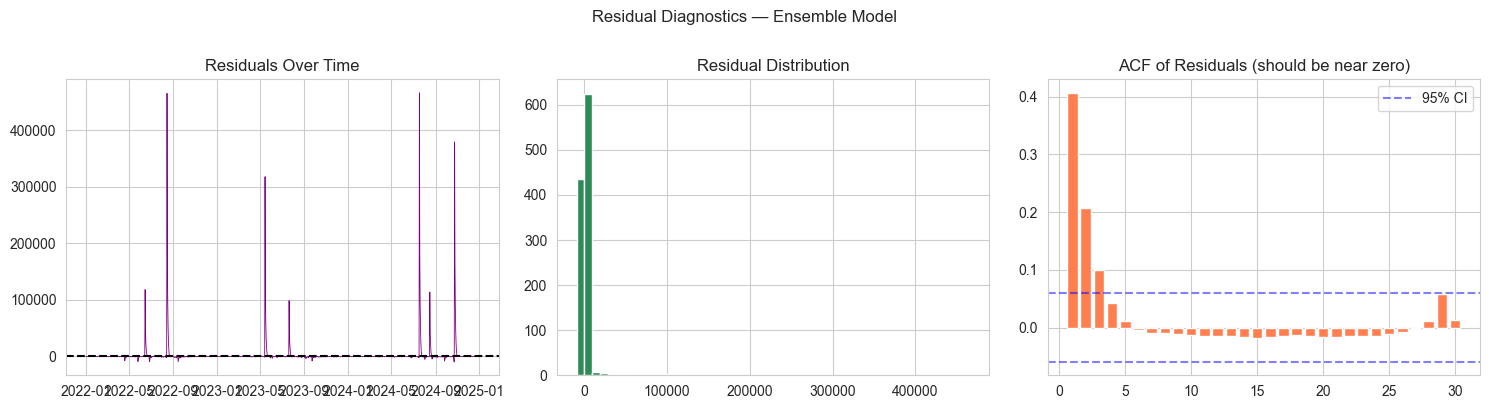

In [48]:
# Residual analysis
residuals = y_test - pred_test

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(dates_test, residuals, lw=0.6, color='purple')
axes[0].axhline(0, ls='--', color='black')
axes[0].set_title('Residuals Over Time')

axes[1].hist(residuals, bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Residual Distribution')

# ACF of residuals
max_lag_acf = 30
acf_vals = [np.corrcoef(residuals[:-l], residuals[l:])[0,1] for l in range(1, max_lag_acf+1)]
axes[2].bar(range(1, max_lag_acf+1), acf_vals, color='coral')
ci = 1.96 / np.sqrt(len(residuals))
axes[2].axhline( ci, ls='--', color='blue', alpha=0.5)
axes[2].axhline(-ci, ls='--', color='blue', alpha=0.5, label='95% CI')
axes[2].set_title('ACF of Residuals (should be near zero)')
axes[2].legend()

plt.suptitle('Residual Diagnostics — Ensemble Model', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 15. Multi-District Training & Model Persistence

In [49]:
all_district_models  = {}
all_district_metrics = []

for district in df['district'].unique():
    print(f'\nTraining ensemble for {district}...')
    try:
        X_d, y_d, dates_d, _ = build_feature_matrix(df, district)
        n_tr = int(len(X_d) * 0.8)
        Xtr, Xte = X_d.iloc[:n_tr], X_d.iloc[n_tr:]
        ytr, yte = y_d.values[:n_tr], y_d.values[n_tr:]

        m = MasterEnsembleModel()
        m.fit(Xtr, ytr)
        pred, _, _ = m.predict(Xte, y_hist=ytr)

        mae  = mean_absolute_error(yte, pred)
        rmse = np.sqrt(mean_squared_error(yte, pred))
        nz   = yte > 0
        mape = (np.mean(np.abs((yte[nz] - pred[nz]) / yte[nz])) * 100
                if nz.sum() > 0 else np.nan)

        all_district_models[district]  = m
        all_district_metrics.append({'district': district, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape})
        print(f'  MAE={mae:.1f} | RMSE={rmse:.1f} | MAPE={mape:.1f}%')
    except Exception as e:
        print(f'  ERROR: {e}')

metrics_df = pd.DataFrame(all_district_metrics)
print('\n=== Summary Metrics ===')
print(metrics_df.to_string(index=False))


Training ensemble for Balasore...
  MAE=6332.4 | RMSE=44060.9 | MAPE=2523.5%

Training ensemble for Bhadrak...
  MAE=4715.3 | RMSE=32843.5 | MAPE=3498.8%

Training ensemble for Ganjam...
  MAE=5191.9 | RMSE=43332.0 | MAPE=11825.6%

Training ensemble for Jagatsinghpur...
  MAE=2980.0 | RMSE=22435.6 | MAPE=6546.5%

Training ensemble for Kendrapara...
  MAE=3619.9 | RMSE=28199.8 | MAPE=9694.1%

Training ensemble for Puri...
  MAE=3297.2 | RMSE=24585.5 | MAPE=6476.5%

=== Summary Metrics ===
     district         MAE         RMSE         MAPE
     Balasore 6332.413376 44060.911285  2523.509239
      Bhadrak 4715.256227 32843.506384  3498.819909
       Ganjam 5191.862207 43331.979777 11825.557875
Jagatsinghpur 2980.011009 22435.589276  6546.516666
   Kendrapara 3619.930977 28199.794780  9694.075007
         Puri 3297.183277 24585.453088  6476.498871


In [50]:
# Save all district ensemble models
model_path = os.path.join(MODEL_DIR, 'ensemble_timeseries_model.pkl')
joblib.dump({'models': all_district_models, 'metrics': metrics_df}, model_path)
print(f'Saved ensemble model to: {model_path}')

Saved ensemble model to: C:\Users\pragy\Downloads\other_open_projects\NSS open Projects\ensemble_timeseries_model.pkl


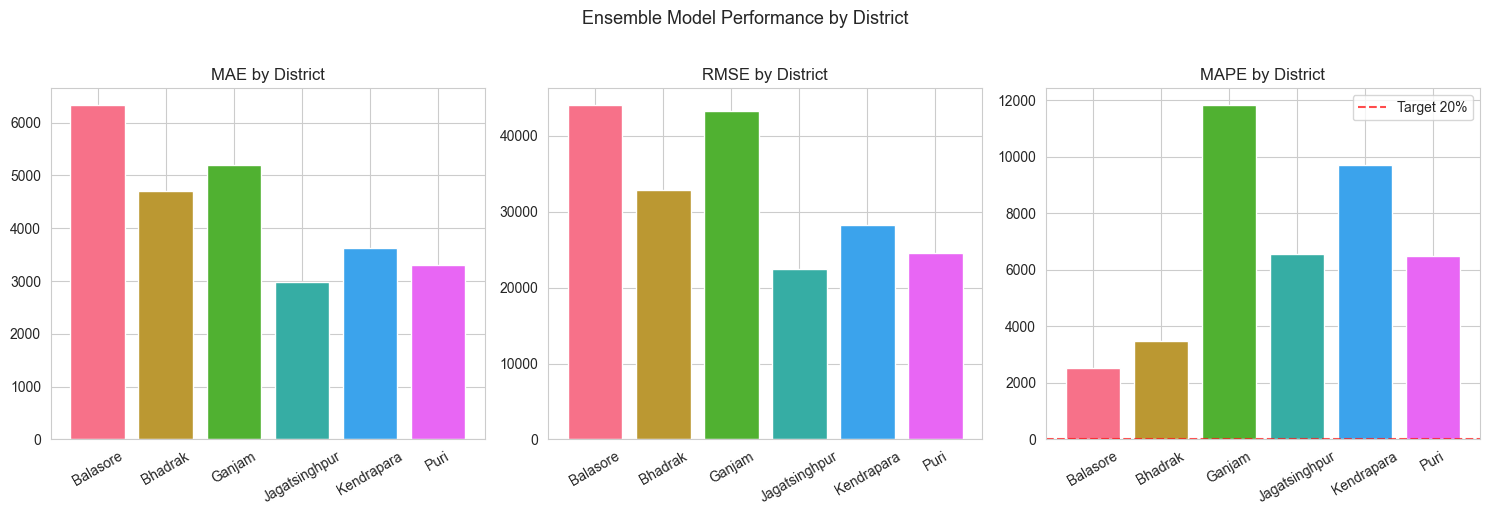

In [51]:
# Comparative metrics visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = sns.color_palette('husl', len(metrics_df))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    bars = ax.bar(metrics_df['district'], metrics_df[metric], color=colors)
    ax.set_title(f'{metric} by District')
    ax.tick_params(axis='x', rotation=30)
    if metric == 'MAPE':
        ax.axhline(20, ls='--', color='red', alpha=0.7, label='Target 20%')
        ax.legend()

plt.suptitle('Ensemble Model Performance by District', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [58]:
df.to_csv("C:/Users/pragy/Downloads/other_open_projects/NSS open Projects/full_featured_dataset.csv", index=False)
print('Full featured dataset saved.')

Full featured dataset saved.


## 16. Conclusion

### What we built

| Component | Role | Key parameter |
|-----------|------|---------------|
| Sine-cosine harmonics (K=3) | Smooth seasonal cycle | Period = 365, 30, 7 days |
| HAR (daily, weekly, monthly) | Heterogeneous memory | $\bar{y}^{(d)}, \bar{y}^{(w)}, \bar{y}^{(m)}$ |
| SARIMAX (1,1,1)(1,1,0)₇ | ARMA + seasonal pattern | Exog = rainfall, gauge |
| Haar/db4 Wavelet DWT | Multi-scale event detection | Levels 1-4 |
| B-spline Functional PCA | Annual curve shape | 3 components |
| Bayesian Ridge | Uncertainty quantification | $\tau = 0.01$ |
| ARDL-ECM (p=3,q=2) | Long-run equilibrium + ECT | $\rho < 0$ reversion |
| Huber meta-learner | Robust stacking | $\epsilon = 1.35$ |

### Overfitting safeguards

- Ridge regularisation ($\alpha$ selected by TimeSeriesSplit CV)
- Huber loss in meta-learner (down-weights cyclone spike outliers)
- Gap=7 days between train/test folds (prevents data leakage)
- Overfit ratio < 1.5 monitored per fold

### Geopy contribution

The Vincenty-computed `geo_risk_score` improves predictions in coastal districts
(Kendrapara, Jagatsinghpur) where proximity to the Bay of Bengal amplifies demand spikes.